In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("murtozalikhon/brain-tumor-multimodal-image-ct-and-mri")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-tumor-multimodal-image-ct-and-mri' dataset.
Path to dataset files: /kaggle/input/brain-tumor-multimodal-image-ct-and-mri


In [2]:
import os
import torch
import torch.nn as nn
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from torchvision.datasets import ImageFolder
from torchvision.transforms import (
    Compose, RandomResizedCrop, RandomHorizontalFlip,
    ToTensor, Resize, CenterCrop
)
from torch.utils.data import DataLoader

In [6]:
data_dir = "/kaggle/input/brain-tumor-multimodal-image-ct-and-mri/Dataset"
train_dir = os.path.join(data_dir, "Brain Tumor MRI images")
val_dir = os.path.join(data_dir,"Brain Tumor CT scan Images")

In [7]:
train_transforms = Compose([
    RandomResizedCrop(224),
    RandomHorizontalFlip(),
    ToTensor()
])
val_transforms = Compose([
    Resize(256),
    CenterCrop(224),
    ToTensor()
])

train_data = ImageFolder(train_dir, transform=train_transforms)
val_data = ImageFolder(val_dir, transform=val_transforms)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)

class_names = train_data.classes
print("Classes:", class_names)

Classes: ['Healthy', 'Tumor']


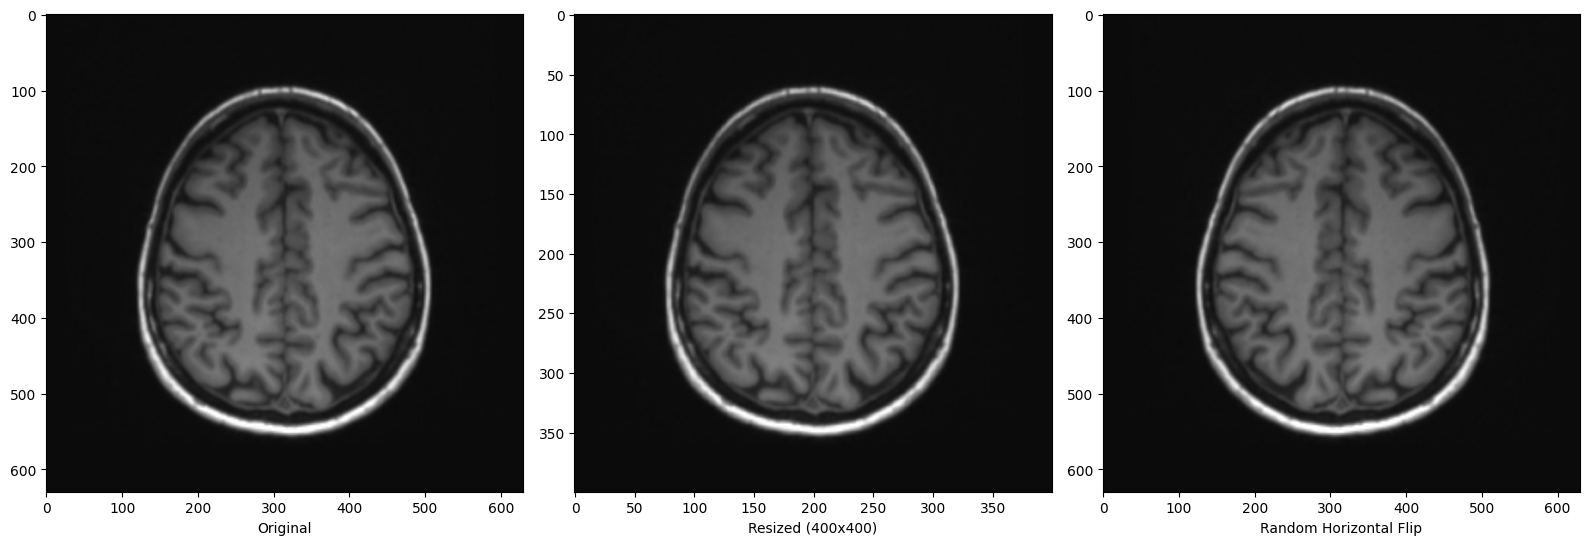

In [8]:
def show_image(img_tensor, label):
    plt.imshow(img_tensor.permute(1, 2, 0))
    plt.xlabel(label)

img, label = ImageFolder(train_dir)[0]
plt.figure(figsize=(16, 9))

plt.subplot(1, 3, 1)
show_image(ToTensor()(img), "Original")

plt.subplot(1, 3, 2)
resized_tensor = ToTensor()(Resize(400)(img))
show_image(resized_tensor, "Resized (400x400)")

plt.subplot(1, 3, 3)
flipped_tensor = ToTensor()(RandomHorizontalFlip(p=1.0)(img))
show_image(flipped_tensor, "Random Horizontal Flip")

plt.tight_layout()
plt.show()

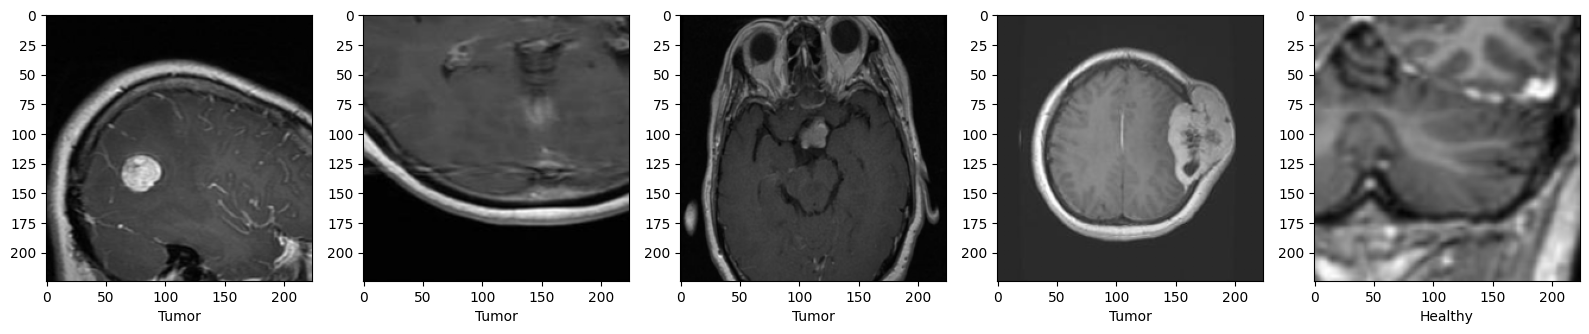

In [9]:
data_batch, label_batch = next(iter(train_loader))
data_batch, label_batch = data_batch[:5], label_batch[:5]

plt.figure(figsize=(16, 9))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(data_batch[i].permute(1, 2, 0))
    plt.xlabel(class_names[label_batch[i]])
plt.tight_layout()
plt.show()

In [10]:
model_ft = torchvision.models.resnet18(pretrained=True)
model_ft.fc = nn.Linear(model_ft.fc.in_features, 4)

# Freeze all layers except the final layer
for name, param in model_ft.named_parameters():
    if name not in ["fc.weight", "fc.bias"]:
        param.requires_grad = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_ft = model_ft.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 137MB/s]


In [11]:
def train(model, train_loader, val_loader, device, num_epochs=3, learning_rate=0.001, decay_lr=False):
    model.train()
    optimizer = torch.optim.Adam(model.fc.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss()

    if decay_lr:
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.85)

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        if decay_lr:
            scheduler.step()

        total_loss = 0
        for batch_idx, (data, labels) in enumerate(train_loader):
            data, labels = data.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(data)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            if batch_idx % 5 == 0:
                print(f"  Batch {batch_idx}/{len(train_loader)}, Loss: {loss.item():.4f}")
        print(f"Epoch {epoch+1} Loss: {total_loss:.4f}")

In [12]:
train(model_ft, train_loader, val_loader, device, num_epochs=1)


Epoch 1/1
  Batch 0/157, Loss: 2.0090
  Batch 5/157, Loss: 0.7231
  Batch 10/157, Loss: 0.6373
  Batch 15/157, Loss: 0.6138
  Batch 20/157, Loss: 0.5993
  Batch 25/157, Loss: 0.6336
  Batch 30/157, Loss: 0.5463
  Batch 35/157, Loss: 0.4339
  Batch 40/157, Loss: 0.4273
  Batch 45/157, Loss: 0.5659
  Batch 50/157, Loss: 0.4428
  Batch 55/157, Loss: 0.6680
  Batch 60/157, Loss: 0.3892
  Batch 65/157, Loss: 0.3467
  Batch 70/157, Loss: 0.3180
  Batch 75/157, Loss: 0.3141
  Batch 80/157, Loss: 0.3392
  Batch 85/157, Loss: 0.4669
  Batch 90/157, Loss: 0.3382
  Batch 95/157, Loss: 0.3538
  Batch 100/157, Loss: 0.3894
  Batch 105/157, Loss: 0.3994
  Batch 110/157, Loss: 0.5102
  Batch 115/157, Loss: 0.2773
  Batch 120/157, Loss: 0.4760
  Batch 125/157, Loss: 0.3974
  Batch 130/157, Loss: 0.3503
  Batch 135/157, Loss: 0.2454
  Batch 140/157, Loss: 0.2394
  Batch 145/157, Loss: 0.2115
  Batch 150/157, Loss: 0.3728
  Batch 155/157, Loss: 0.2405
Epoch 1 Loss: 70.7296


In [13]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

def visualize_predictions(model, data_loader, device, classes=None, num_images_to_show=5):
    model.eval()

    try:
        data, labels = next(iter(data_loader))
    except StopIteration:
        print("Data loader is empty. Cannot visualize predictions.")
        return

    data, labels = data.to(device), labels.to(device)

    with torch.no_grad():
        outputs = model(data)
        _, predicted_classes = torch.max(outputs, 1)

        if classes:
            predicted_labels_text = [classes[p.item()] for p in predicted_classes]
            true_labels_text = [classes[l.item()] for l in labels]
        else:
            predicted_labels_text = predicted_classes.tolist()
            true_labels_text = labels.tolist()

        num_images_to_show = min(num_images_to_show, data.size(0))
        fig, axes = plt.subplots(1, num_images_to_show, figsize=(15, 4))
        if num_images_to_show == 1:
            axes = [axes]

        for i in range(num_images_to_show):
            img = data[i].cpu().numpy()

            if img.shape[0] == 3:
                img = np.transpose(img, (1, 2, 0))

            img = np.clip(img, 0, 1)

            axes[i].imshow(img)
            axes[i].set_title(f"Pred: {predicted_labels_text[i]}\nTrue: {true_labels_text[i]}")
            axes[i].axis('off')
        plt.tight_layout()
        plt.show()

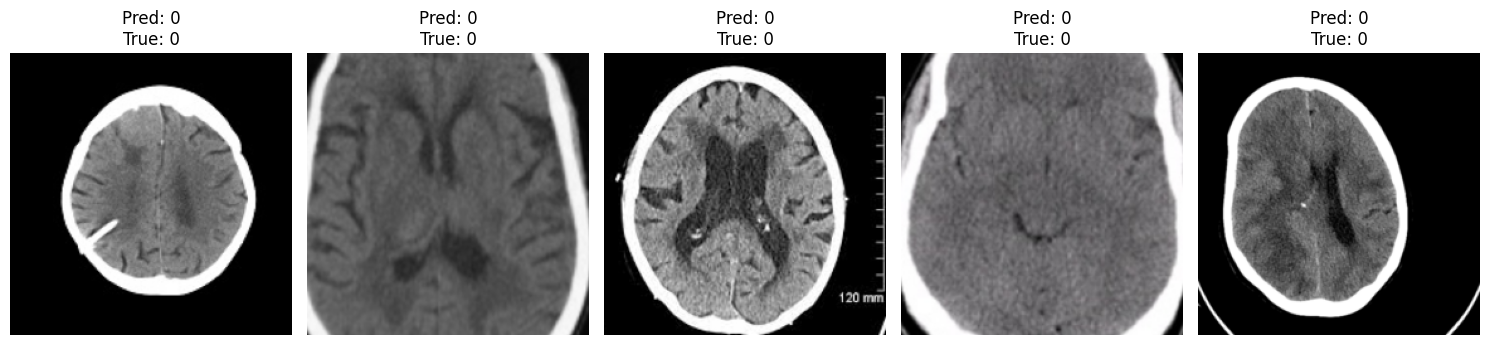

In [14]:
visualize_predictions(model_ft, val_loader,device,num_images_to_show=5)